# Chapter 5 — Pretraining on Unlabeled Data

We import the GPT model built in chapter 4 and instantiate it with a shorter `context_length` (256) to keep training cheap.

In [1]:
import torch
from chapter04 import GPTModel

GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 256,
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.1,
    "qkv_bias": False,
}

model = GPTModel(GPT_CONFIG_124M)
model.eval() 

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (attn): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='tanh')
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (norm1): LayerNorm()
      (norm2): LayerNorm

In [2]:
from chapter04 import generate_text_simple
import tiktoken

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    # add a single batch dimension: [seq_len] -> [1, seq_len]
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0)  # remove batch dim
    return tokenizer.decode(flat.tolist())

start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"],
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves youutonium Blaze Update merging punishing soaking legitimateCivil Devula


In [3]:
import os
import urllib.request

# Load "The Verdict" by Edith Wharton — our training corpus.
file_path = "the-verdict.txt"
url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch02/01_main-chapter-code/the-verdict.txt"

if not os.path.exists(file_path):
    urllib.request.urlretrieve(url, file_path)

with open(file_path, "r", encoding="utf-8") as f:
    text_data = f.read()

# Quick stats on the corpus
total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))
print("Characters:", total_characters)
print("Tokens:", total_tokens)
print("\nFirst 100 chars:\n", text_data[:100])


Characters: 20479
Tokens: 5145

First 100 chars:
 I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no g


In [4]:
# Train/validation split: 90% for training, 10% held out for validation.
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

print("train chars:", len(train_data))
print("val chars:  ", len(val_data))


train chars: 18431
val chars:   2048


In [5]:
from chapter02 import create_dataloader_v1

torch.manual_seed(123)
train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0,
)
val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0,
)

# Sanity check: shape   s of one batch and number of batches per loader.
print("Train batches:", len(train_loader))
print("Val batches:  ", len(val_loader))
for x, y in train_loader:
    print("batch x:", x.shape, "batch y:", y.shape)
    break


Train batches: 9
Val batches:   1
batch x: torch.Size([2, 256]) batch y: torch.Size([2, 256])


In [6]:
for x, y in val_loader:
    print(x.shape, y.shape)

torch.Size([2, 256]) torch.Size([2, 256])


In [7]:
import torch.nn.functional as F


def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    logits = model(input_batch)  # use the passed-in model, not a global
    loss = F.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss

In [8]:
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.0
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        # cap at the number of batches available
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches  # average loss across the batches


In [9]:
# Pick the best available device:
#   CUDA (NVIDIA GPU) -> MPS (Apple Silicon GPU) -> CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")  # Apple Metal GPU
else:
    device = torch.device("cpu")
print("Using device:", device)

model.to(device)  # move the model onto the chosen device

# torch.no_grad() disables gradient tracking — we're only measuring loss, not training yet.
with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)


Using device: mps
Training loss: 11.00789123111301
Validation loss: 10.945213317871094


In [10]:
def train_model_simple(model, train_loader, val_loader, optimizer, device,num_epochs,eval_freq,eval_iter,start_context,tokenizer):
    # Track losses (and tokens seen) so we can plot the learning curves afterwards.
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    for epoch in range(num_epochs):
        model.train()  # set the model to training mode
        for i, (input_batch, target_batch) in enumerate(train_loader):
            optimizer.zero_grad()  # reset gradients
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()  # backpropagate
            optimizer.step()  # update parameters
            tokens_seen += input_batch.numel()
            global_step += 1

            if (i + 1) % eval_freq == 0:
                model.eval()  # set the model to evaluation mode
                with torch.no_grad():
                    train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
                    val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
                # record for plotting
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], "
                      f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

                # Generate text after evaluation.
                # NOTE: .to(device) is required — text_to_token_ids builds the tensor on
                # the CPU, but the model lives on `device` (e.g. mps/cuda). Without this,
                # you get: "Placeholder storage has not been allocated on MPS device!"
                token_ids = generate_text_simple(
                    model=model,
                    idx=text_to_token_ids(start_context, tokenizer).to(device),
                    max_new_tokens=10,
                    context_size=GPT_CONFIG_124M["context_length"],
                )
                print("Generated text:\n", token_ids_to_text(token_ids, tokenizer))
                model.train()  # switch back to training mode for the rest of the epoch

    return train_losses, val_losses, track_tokens_seen


In [11]:
# Train the model.
torch.manual_seed(123)

# The optimizer is bound to the model via model.parameters() — those tensor
# references are what optimizer.step() updates during training.
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)

num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs,
    eval_freq=5,      # evaluate every 5 training steps
    eval_iter=5,      # average loss over 5 batches when evaluating
    start_context="Every effort moves you",
    tokenizer=tokenizer,
)


Epoch [1/10], Step [5/9], Train Loss: 10.4111, Val Loss: 10.4551
Generated text:
 Every effort moves you ay't paralleBegland soBe't't't
Epoch [2/10], Step [5/9], Train Loss: 8.1906, Val Loss: 8.4032
Generated text:
 Every effort moves you a was a was was was was a was was
Epoch [3/10], Step [5/9], Train Loss: 6.5883, Val Loss: 7.0395
Generated text:
 Every effort moves you a a a a a a a a a a
Epoch [4/10], Step [5/9], Train Loss: 6.1500, Val Loss: 6.7056
Generated text:
 Every effort moves you of-- of-- of-- of-- of--
Epoch [5/10], Step [5/9], Train Loss: 6.0421, Val Loss: 6.7216
Generated text:
 Every effort moves you,,,,,,,,,,
Epoch [6/10], Step [5/9], Train Loss: 6.0121, Val Loss: 6.7377
Generated text:
 Every effort moves you,,,,,,,,,,
Epoch [7/10], Step [5/9], Train Loss: 6.0207, Val Loss: 6.7733
Generated text:
 Every effort moves you,,
,,,
,,,
Epoch [8/10], Step [5/9], Train Loss: 6.0513, Val Loss: 6.7899
Generated text:
 Every effort moves you,,,,,,,,,,
Epoch [9/10], Step [5/9]

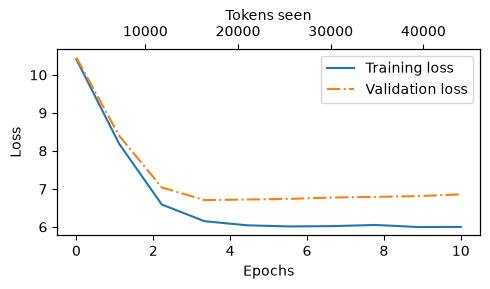

In [12]:
import matplotlib.pyplot as plt


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Primary x-axis: epochs.
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")

    # Secondary x-axis: tokens seen (shares the same line, just relabeled).
    ax2 = ax1.twiny()
    ax2.plot(tokens_seen, train_losses, alpha=0)  # invisible — only to set the scale
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()
    plt.show()


# train_losses/val_losses have one entry per evaluation step, so map them onto
# a fractional-epoch axis for the x-coordinates.
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)


In [13]:
## looks like it's overfitting -> expected due to the small dataset size

In [14]:
model.to("cpu")
model.eval()  # set the model to evaluation mode
tokenizer = tiktoken.get_encoding("gpt2")
token_ids = generate_text_simple(model=model,idx=text_to_token_ids("Every effort moves you", tokenizer),max_new_tokens=25,context_size=GPT_CONFIG_124M["context_length"])
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you,,,,,,,,,,,,,,,,,,,,,,,,,
